<a href="https://colab.research.google.com/github/parika8ec-hub/DataScience_Project_BIA/blob/Labs/Lesson_14_lab_ethical_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Ethical Analysis and Explanability exercise**


This exercise aims to build, analyze, and interpret a machine learning model while focusing on fairness and explainability.

- **Building:** This involves training a machine learning model on a given dataset. It is important to ensure the model is accurate and generalizes well to unseen data.
- **Analyzing:** This step focuses on evaluating the performance of the model, not just in terms of accuracy but also in terms of fairness. We want to ensure that the model does not discriminate against certain groups.
- **Interpreting:** This involves understanding how the model makes its decisions. This is important for both debugging the model and for building trust in the system.

### Why Fairness and Explainability Matter for Ethical Analysis

- **Fairness:** In many applications, it is crucial that machine learning models do not discriminate against certain groups. For example, in loan applications, we want to ensure that the model does not unfairly deny loans to certain demographics.
- **Explainability:** Understanding how a model makes its decisions is crucial for building trust in the system. If users cannot understand why a model made a certain decision, they are less likely to trust it. Additionally, explainability can help identify potential biases or errors in the model.

By focusing on both fairness and explainability, we can build machine learning models that are not only accurate but also ethical and trustworthy.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, true_positive_rate
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
import joblib
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

In [ ]:
# 1. Load and Prepare Data
# Load dataset from a public URL and read it into a pandas DataFrame
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv'
columns = ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree', 'age', 'outcome']
data = pd.read_csv(url, names=columns)

# Check columns
print(data.columns)

# Preprocessing
X = data.drop(columns=['outcome'])
X = pd.get_dummies(X, drop_first=True)  # Ensure all features are numeric

# Target encoding
y = data['outcome']

# Sensitive feature encoding (using 'age' as a proxy for fairness)
sensitive_feature = pd.cut(data['age'], bins=[20, 30, 40, 50, 60, 100], labels=['20-30', '30-40', '40-50', '50-60', '60+'])

# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Handle Imbalanced Data
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


Index(['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin',
       'bmi', 'diabetes_pedigree', 'age', 'outcome'],
      dtype='object')


In [ ]:

# 2. Train Logistic Regression Model
# Initialize a logistic regression model with 1000 iterations for convergence
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Performance Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7337662337662337
Confusion Matrix:
 [[75 25]
 [16 38]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



       accuracy  selection_rate  false_positive_rate  true_positive_rate
age                                                                     
20-30  0.764045        0.235955             0.169014            0.500000
30-40  0.703704        0.592593             0.333333            0.722222
40-50  0.750000        0.708333             0.454545            0.923077
50-60  0.555556        0.666667             0.600000            0.750000
60+    0.600000        0.600000             0.500000            1.000000


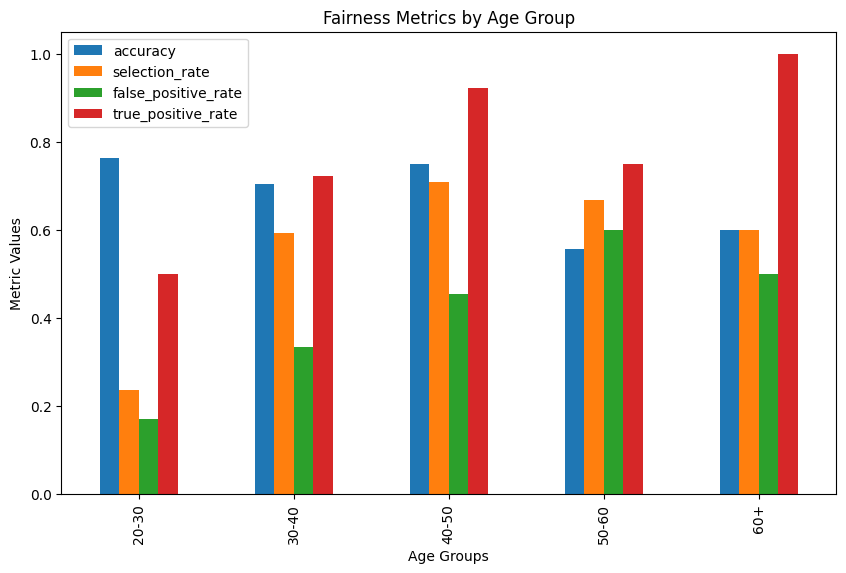

In [ ]:
# 3. Fairness Analysis using Fairlearn
# Create a MetricFrame to compute fairness metrics by group
metric_frame = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'selection_rate': selection_rate,
        'false_positive_rate': false_positive_rate,
        'true_positive_rate': true_positive_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_feature[X_test.index]
)
print(metric_frame.by_group)
metric_frame.by_group.plot(kind='bar', figsize=(10, 6))
plt.title("Fairness Metrics by Age Group")
plt.ylabel("Metric Values")
plt.xlabel("Age Groups")
plt.show()


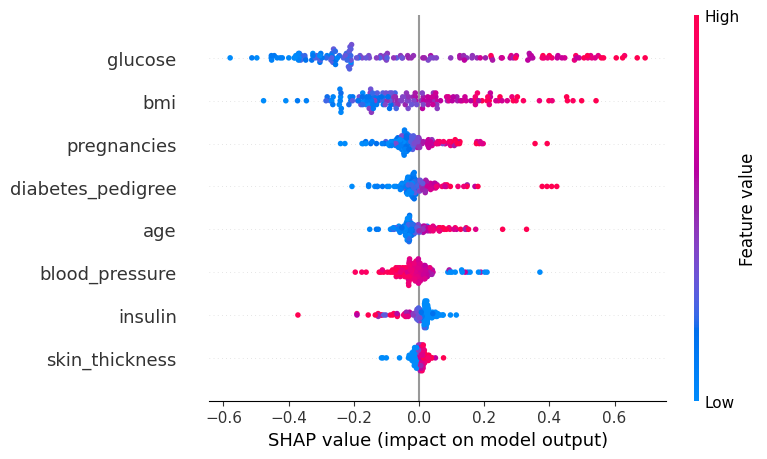

In [ ]:
# 4. Explainability Analysis
# SHAP Analysis
explainer = shap.Explainer(model.predict, X_test)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

In [ ]:
# LIME Analysis
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns,
    class_names=['Non-Diabetic', 'Diabetic'],
    mode='classification'
)
exp = explainer.explain_instance(X_test.iloc[0], model.predict_proba)
exp.show_in_notebook(show_table=True)


In [ ]:
# 5. Save Model
joblib.dump(model, 'fairness_model_v1.pkl')

# Example Application Discussion
example_application = "This model can be deployed in healthcare systems for diabetes prediction, ensuring fairness and transparency. Bias mitigation techniques should be integrated to avoid discrimination against specific age groups."